Comparação entre Bubblesort, Bogosort e SmartBogosort

In [8]:
# bibliotecas

import numpy as np
import matplotlib.pyplot as plt
import random
import os

 Tamanho: 1 concluído
 Tamanho: 2 concluído
 Tamanho: 3 concluído
 Tamanho: 4 concluído
 Tamanho: 5 concluído
 Tamanho: 6 concluído
 Tamanho: 7 concluído
 Tamanho: 8 concluído
 Tamanho: 9 concluído


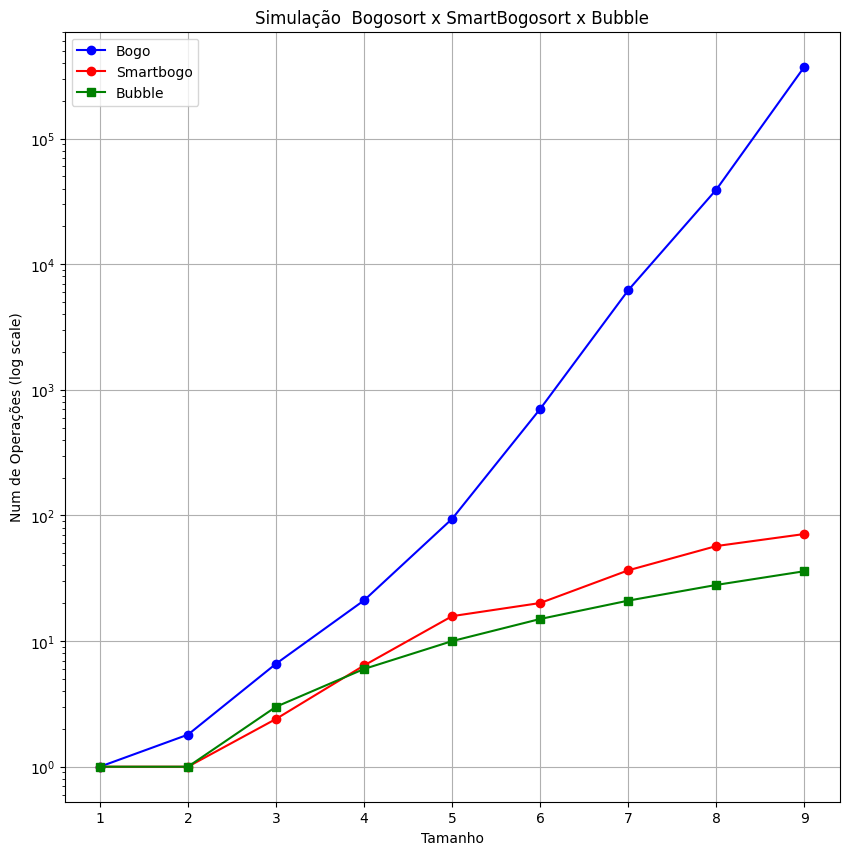

In [3]:
def is_sorted(arr):
    "Verificar se o vetor está ordenado"
    for i in range(len(arr) - 1):
        if arr[i] > arr[i+1]:
            return False
    return True

def bogosort(arr):
    "Embaralha o vetor até ele estar ordenado"
    tentativas = 0
    while not is_sorted(arr):
        random.shuffle(arr)
        tentativas += 1
    return max(1, tentativas)

def bubblesort(arr):
    "Ordenação por trocas adjacentes (determinístico)"
    n = len(arr)
    comparacoes = 0
    for i in range(n):
        for j in range(0, n-i-1):
            comparacoes += 1
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return max(1, comparacoes)

def smart_bogosort(arr):
    "sorteia o indice e realiza a troca apenas quando a[i] > a[i+1], 'tem memoria' "
    n = len(arr)
    tentativas = 0
    while not is_sorted(arr):
        i = random.randint(0,n-2)
        # i,j = random.randint(0,n-1), random.randint(0, n-1) - Fica pior que o bogosort clássico
        j = i+1
        tentativas += 1

        if i != j and arr[i] > arr[j]:
            arr[i], arr[j] = arr[j], arr[i]
    return max(1, tentativas)


def main():
  tamanho = [1,2,3,4,5,6,7,8,9]
  n_simulacoes = 10

  res_bogo = []
  res_bubble = []
  res_smartbogo = []

  for n in tamanho:
      bogo_avg, smartbogo_avg, bubble_avg = 0,0,0
      for i in range(n_simulacoes):
          vetor = list(range(1, n+1))
          random.shuffle(vetor)

          bogo_avg += bogosort(vetor.copy())
          smartbogo_avg += smart_bogosort(vetor.copy())
          bubble_avg += bubblesort(vetor.copy())

      res_bogo.append(bogo_avg/n_simulacoes)
      res_smartbogo.append(smartbogo_avg/n_simulacoes)
      res_bubble.append(bubble_avg/n_simulacoes)
      print(f" Tamanho: {n} concluído")


  fig, ax = plt.subplots(figsize=(10,10))

  ax.plot(tamanho, res_bogo, label="Bogo", color="blue", marker="o")
  ax.plot(tamanho, res_smartbogo, label="Smartbogo", color="red", marker="o")
  ax.plot(tamanho, res_bubble, label="Bubble", color="green", marker="s")

  ax.set_title("Simulação  Bogosort x SmartBogosort x Bubble")
  ax.set_xlabel("Tamanho")
  ax.set_ylabel("Num de Operações (log scale)")
  ax.grid(True)
  ax.set_yscale("log")
  plt.legend()
  plt.show()
main()

O gráfico, em escala logarítimica, mostra uma grande correlação entre o tamanho e o número de operações. É possível notar que  a curva do SmartBogosort tem um crescimento polinomial que acompanha o $O(n^2)$ do Bubblesort, ao passo que para o algoritmo clássico do BogoSort, segue um crescimento da ordem de $O(n*n!)$

Geração de números normais usando Box-Muller

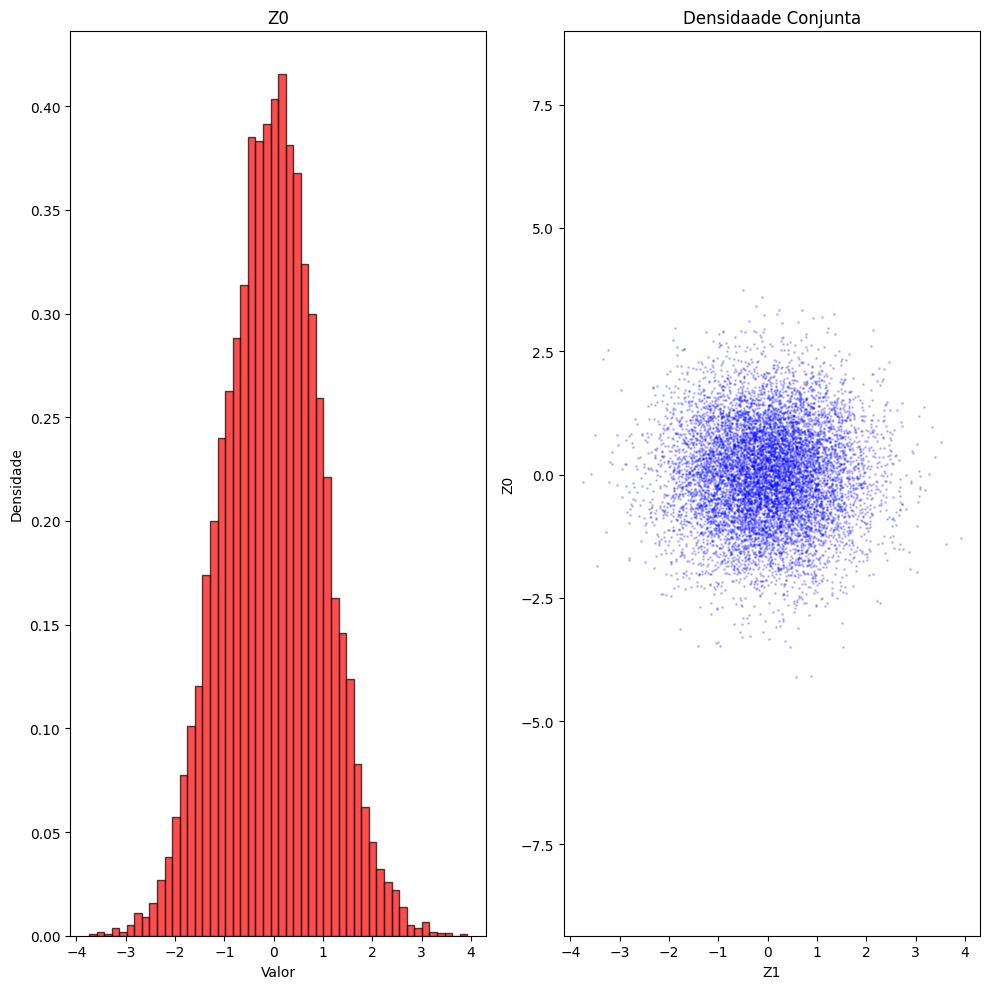

In [4]:

def box_muller(n):
    "Gera números que seguem uma distribuição normal, N(0,1), a partir de distribuições uniformes, U(0,1), usando Box_Muller"
    u1 = np.random.uniform(0,1,n)
    u2 = np.random.uniform(0,1,n)
    z0 = np.sqrt(-2*np.log(u1)) * np.cos(2*np.pi*u2)
    z1 = np.sqrt(-2*np.log(u1)) * np.sin(2*np.pi*u2)

    return z0, z1


def main():
  n = 10000
  gauss1,gauss2 = box_muller(n)

  fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,10))

  ax1.hist(gauss1,bins=50, density=True, color='red',edgecolor="black", alpha=0.7, label='gauss1')
  ax1.set_title('Z0')
  ax1.set_ylabel('Densidade')
  ax1.set_xlabel('Valor')

  ax2.scatter(gauss1,gauss2, s=1, color='blue', alpha=0.2 )
  ax2.set_title('Densidaade Conjunta')
  ax2.set_ylabel('Z0')
  ax2.set_xlabel('Z1')
  ax2.axis('equal')
  plt.tight_layout()
  plt.show()
main()

Z0 tem o formato de sino, característica classica de uma curva gaussiana.  O gráfico de dispersão (em azul), mostra uma nuvem circular de pontos concentrada no centro, uma vez que o seno e o cosseno espalham os pontos em todas as direções de forma igual, e o logaritmo empurra a maioria dos pontos para perto do zero.

Modelagem e Simulação da figura 4.3

<Figure size 640x480 with 0 Axes>

Sequência LCG: ['0.020', '0.017', '0.543', '0.635', '0.910'] ...
Sequência LOG: ['0.433', '0.982', '0.071', '0.263', '0.776'] ...


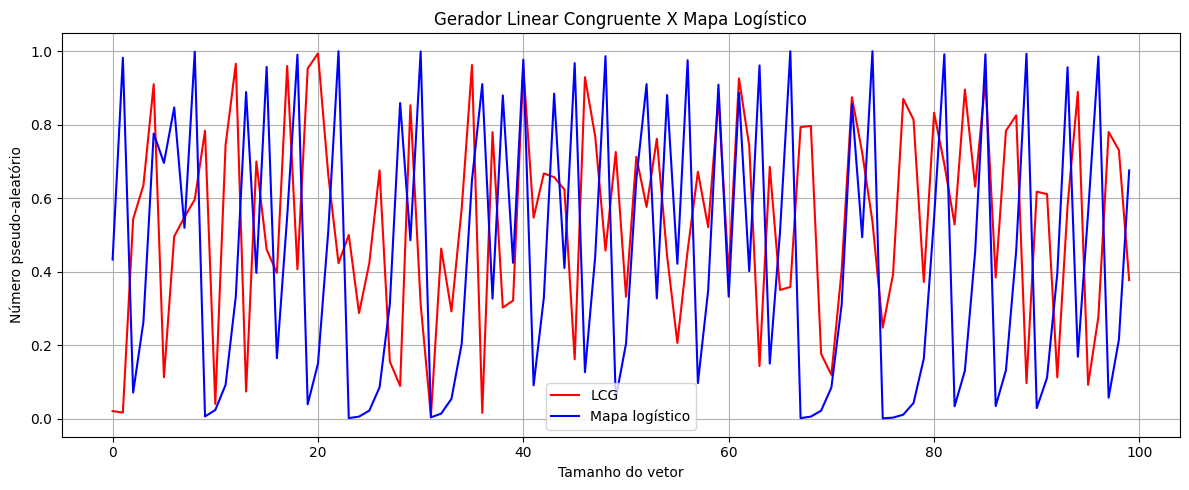

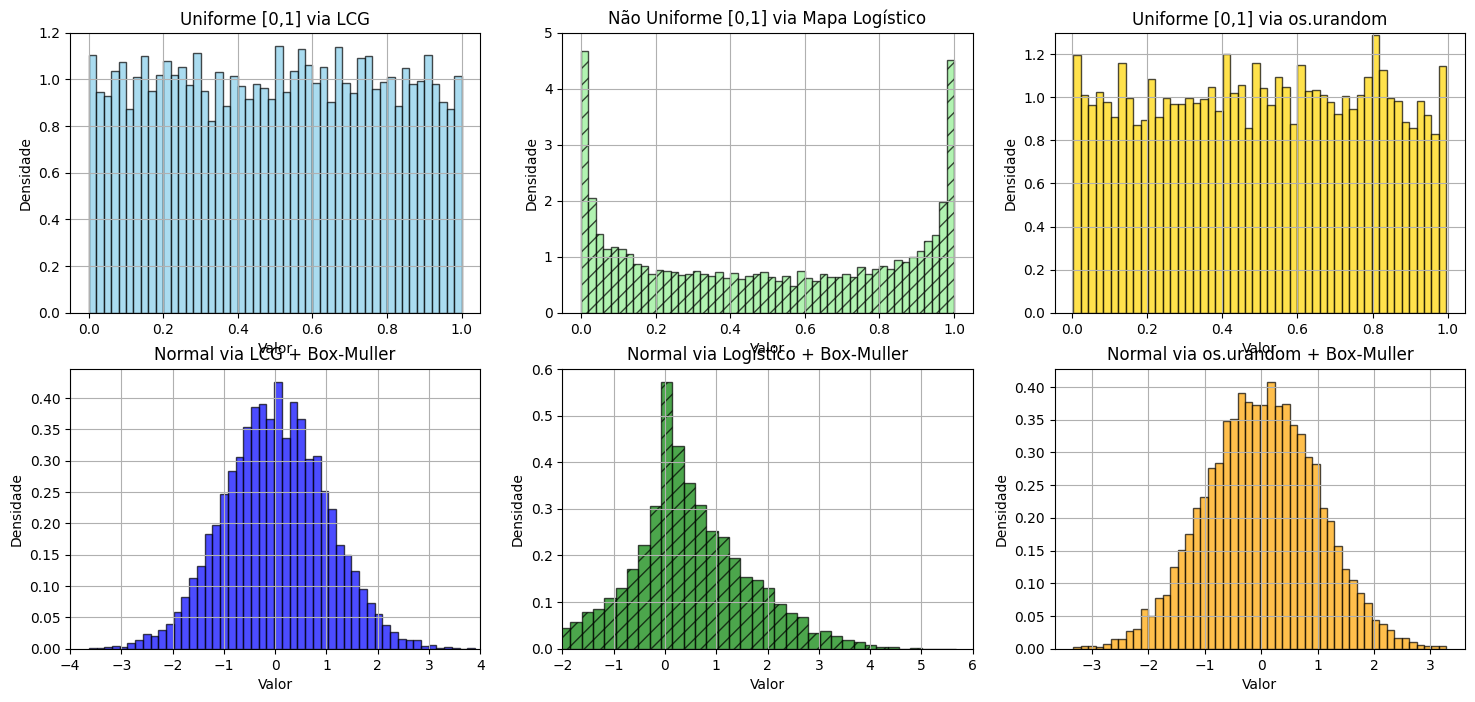

In [13]:

N = 10000
def lgc(x0,a,c,m):
  arr = []
  x = x0
  for i in range(N):
    x = (a * x + c) % m
    if x/m == 0:
       arr.append(1e-10)
    else:
      arr.append(x / m)
  return arr
def mapa_logistico(x1,r):
    arr = []
    x=x1
    for i in range(N):
        x = r * x * (1 - x)
        arr.append(x)
    return arr
def distribuicao_uniforme():
  return np.array([(b + 1) / 257.0 for b in os.urandom(N)])

def box_muller(u1, u2):
    u1 = np.array(u1)
    u2 = np.array(u2)
    z0 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
    z1 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)

    return z0, z1

def main():
  u_lcg = lgc(12345, 1664525, 1013904223, 2**32)
  v_lcg = lgc(67890, 1664525, 1013904223, 2**32)
  z_lcg = box_muller(u_lcg, v_lcg)[0]

  u_log = mapa_logistico(0.123456, 4)
  v_log = mapa_logistico(0.654321, 4)
  z_log = box_muller(u_log, v_log)[0]

  u_urand = distribuicao_uniforme()
  v_urand = distribuicao_uniforme()
  z_urand = box_muller(u_urand, v_urand)[0]

  print("Sequência LCG:", [f"{x:.3f}" for x in u_lcg[:5]], "...")
  print("Sequência LOG:", [f"{x:.3f}" for x in u_log[:5]], "...")

  plotLimit = 100

  plt.figure(figsize=(12, 5))
  plt.plot(u_lcg[0:plotLimit], '-', label='LCG', color='red')
  plt.plot(u_log[0:plotLimit], '-', label='Mapa logístico', color='blue')
  plt.xlabel('Tamanho do vetor')
  plt.ylabel('Número pseudo-aleatório')
  plt.title('Gerador Linear Congruente X Mapa Logístico')
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()


  fig, axes = plt.subplots(2, 3, figsize=(18, 8))

  axes[0, 0].hist(u_lcg, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
  axes[0, 0].set_title("Uniforme [0,1] via LCG")
  axes[0, 0].set_ylim(0, 1.2)

  axes[0, 1].hist(u_log, bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black', hatch='//')
  axes[0, 1].set_title("Não Uniforme [0,1] via Mapa Logístico")
  axes[0, 1].set_ylim(0, 5)

  axes[0, 2].hist(u_urand, bins=50, density=True, alpha=0.7, color='gold', edgecolor='black')
  axes[0, 2].set_title("Uniforme [0,1] via os.urandom")
  axes[0, 2].set_ylim(0, 1.3)

  axes[1, 0].hist(z_lcg, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
  axes[1, 0].set_title("Normal via LCG + Box-Muller")
  axes[1, 0].set_xlim(-4, 4)

  axes[1, 1].hist(z_log, bins=50, density=True, alpha=0.7, color='green', edgecolor='black', hatch='//')
  axes[1, 1].set_title("Normal via Logístico + Box-Muller")
  axes[1, 1].set_xlim(-2, 6)

  axes[1, 2].hist(z_urand, bins=50, density=True, alpha=0.7, color='orange', edgecolor='black')
  axes[1, 2].set_title("Normal via os.urandom + Box-Muller")

  for ax in axes.flat:
      ax.set_xlabel("Valor")
      ax.set_ylabel("Densidade")
      ax.grid(True)

plt.tight_layout()
plt.show()


main()

Uniforme via LCG e os.urandom apresentam uma densidade próxima de $1.0$ no intervalo $[0, 1]$. Com o eixo Y fixado em torno de $1.2$ nota-seos valores estão bem distribuídos.  Já a Não Uniforme via Mapa Logísticom, a densidade nas bordas alcança para quase 5, poiso caos no mapa logístico gera números que se acumulam nas extremidades, não sendo bem distribuídos.

Ao aplicar a Transformada de Box-Mulle, a Normal via LCG e os.urandom: Como as entradas eram uniformes, o método de Box-Muller foi efetivo, os gráficos tem o formato de sino centrado no zero. Já o Normal via Logístico é visivelmente distorcida, uma  vez que o pico é muito mais acentuado e a base se estende de forma assimétrica, o que mostraa fonte não ser uniforme invalida a transformação para uma Normal padrão.